# Usage examples for datamanager

## Importing multipe formats

Import multichannel recordings from multiple formats with the exact same code.

For instance, the code below imports and prints properties for the currently supported formats :
1. **MCS recordings** converted to hdf5 format
2. **Intan RHD recordings**
3. **Binary recording files**

In [4]:
from datamanager import manager as dm

testdata_folder = "../../testdata"

data_to_import = []
data_to_import.append(("MCS hdf5"      , testdata_folder + "/20210601_HD4_WT_downsampling.h5"                 , "D1"))
data_to_import.append(("Intan RHD"     , testdata_folder + "/Perf_noise nouveau compresseur_201211_152948.rhd", "A-008"))
data_to_import.append(("Generic binary", testdata_folder + "/20211101_SYAMV1_DAQ_MEA_heaton.bin"              , "0"))

for description, data_path,ch in data_to_import:
    print(f"=========== Loading {description} file : {data_path} ===========")
    DS = dm.DataSource(data_path)
    DS.load()
    
    print("> Available channels :", DS.getChannels())
    print("> Sampling frequency :", DS.Fs, "Hz")
    print("> Samples :", DS[ch], "\n"*3)

=========== Loading MCS hdf5 file : ../../testdata/20210601_HD4_WT_downsampling.h5 ===========
MCS import - autoloading (cycling versions)
  Success for <class 'McsPy.McsData.RawData'>
Recording_0 <HDF5 group "/Data/Recording_0" (1 members)>
Stream_0 <HDF5 group "/Data/Recording_0/AnalogStream/Stream_0" (3 members)>
ChannelData <HDF5 dataset "ChannelData": shape (60, 672100), type "<i4">
ChannelDataTimeStamps <HDF5 dataset "ChannelDataTimeStamps": shape (1, 3), type "<i8">
InfoChannel <HDF5 dataset "InfoChannel": shape (60,), type "|V108">
> Available channels : ['H6', 'A5', 'D2', 'H3', 'F6', 'A4', 'Ref', 'F5', 'C4', 'F1', 'J3', 'D8', 'D5', 'F3', 'J4', 'C7', 'C3', 'E3', 'H5', 'B6', 'C1', 'G3', 'G6', 'B5', 'D1', 'F7', 'B4', 'E1', 'E7', 'B3', 'F2', 'G4', 'E5', 'A1', 'G2', 'F4', 'D6', 'B1', 'J1', 'G5', 'E4', 'D3', 'J2', 'G7', 'C5', 'D4', 'F8', 'A3', 'E2', 'E6', 'A2', 'G1', 'H4', 'D7', 'B2', 'H1', 'J5', 'C6', 'C2', 'H2']
> Sampling frequency : 100.0 Hz
> Samples : [ -0.022721  -2.067611   

## Importing signal from one channel

MCS import - autoloading (cycling versions)
  Success for <class 'McsPy.McsData.RawData'>
Recording_0 <HDF5 group "/Data/Recording_0" (1 members)>
Stream_0 <HDF5 group "/Data/Recording_0/AnalogStream/Stream_0" (3 members)>
ChannelData <HDF5 dataset "ChannelData": shape (60, 672100), type "<i4">
ChannelDataTimeStamps <HDF5 dataset "ChannelDataTimeStamps": shape (1, 3), type "<i8">
InfoChannel <HDF5 dataset "InfoChannel": shape (60,), type "|V108">


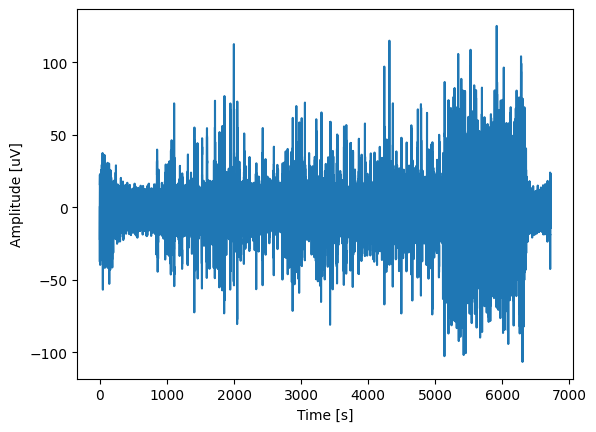

In [7]:
from matplotlib import pyplot as plt
import numpy as np

data_path = "../../testdata/20210601_HD4_WT_downsampling.h5"
DS = dm.DataSource(data_path)
DS.load()

signal = DS["D1"]
time = np.linspace(0, len(signal)/DS.Fs, len(signal))

plt.figure()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [uV]")
plt.plot(time, signal)
plt.show()

## Importing a specific signal chunk from one channel

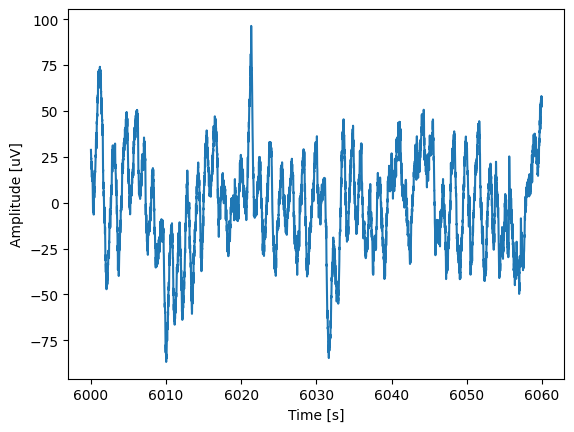

In [8]:
bounds_s = (6000, 6060)
signal = DS.getSignal(ch="D1", bounds_s=bounds_s)
time = np.linspace(*bounds_s, len(signal))

plt.figure()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [uV]")
plt.plot(time, signal)
plt.show()